In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "wishlists/adds.xlsx"


# Read all files into DataFrames and add filename column
adds = pd.read_excel(folder_path, skiprows=2)

adds.rename({"Selected Measure":"additions"}, axis=1, inplace=True)

In [3]:
adds.query("product=='Wanderstop'")

,Day,product,additions,Blank Measure
43,2018-01-01,Wanderstop,0,NaN
91,2018-01-02,Wanderstop,0,NaN
139,2018-01-03,Wanderstop,0,NaN
187,2018-01-04,Wanderstop,0,NaN
235,2018-01-05,Wanderstop,0,NaN
...,...,...,...,...
132896,2025-05-30,Wanderstop,506,NaN
132947,2025-05-31,Wanderstop,527,NaN
132998,2025-06-01,Wanderstop,523,NaN
133049,2025-06-02,Wanderstop,64,NaN


In [4]:
folder_path = "wishlists/activations.xlsx"


activations  = pd.read_excel(folder_path, skiprows=2)

activations.rename({"Selected Measure":"activations"}, axis=1, inplace=True)

In [5]:
adds = adds.drop("Blank Measure", axis=1)
activations = activations.drop("Blank Measure", axis=1)

In [6]:
adds.drop_duplicates("product").to_clipboard()

In [7]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"


dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')

In [8]:
dates

,product,pc_release_date
0,Faraway,2025-12-31
1,Mixtape,2025-12-31
2,The Lost Wild,2026-11-01
3,Wheel World,2025-07-23
4,BattleSage,2025-06-30
5,to a T,2025-05-28
6,Skin Deep,2025-04-30
7,Lushfoil Photography Sim,2025-04-15
8,Wanderstop,2025-03-11
9,Morsels,2025-02-28


In [9]:
df = pd.merge(adds, activations, on=['product', 'Day'], how='left')

In [10]:
dates['product'].unique()

array(['Faraway', 'Mixtape', 'The Lost Wild', 'Wheel World', 'BattleSage',
       'to a T', 'Skin Deep', 'Lushfoil Photography Sim', 'Wanderstop',
       'Morsels', 'Flock', 'Lorelei and the Laser Eyes', 'Open Roads',
       'Thirsty Suitors', 'Cocoon', 'Storyteller', 'Solar Ash',
       'Hindsight', 'Hohokum', 'Stray', 'Neon White', 'A Memoir Blue',
       'The Pathless', 'The Artful Escape', 'Twelve Minutes', 'Last Stop',
       'Mundaun', 'Maquette', 'Wattam', 'Due Process', 'I Am Dead',
       'The Unfinished Swan', 'Outer Wilds', 'Journey', 'If Found...',
       'Florence', 'Kentucky Route Zero: TV Edition',
       'Sayonara Wild Hearts', 'Ashen', 'Telling Lies', 'Flower',
       'Donut County', 'Gorogoa', 'What Remains of Edith Finch'],
      dtype=object)

In [11]:
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
df['release_date'] = pd.to_datetime(df['Day'])


In [12]:
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [13]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser Eyes': Timestamp('2024-05-16 00:00:00'),
 'Lushfoil Photography Sim': Timestamp('2025-04-15 00:00:00'

In [14]:
df['release_date'] = df['product'].map(release_date_dict)


In [15]:
df["DBR"] = (df["Day"] - df["release_date"]).dt.days


In [16]:
df["Weeks_from_Release"] = (df["DBR"] // 7) + 1  # Week 1 starts at 0-7 days


In [17]:
df['cumulative_additions'] = df.groupby('product')['additions'].cumsum()
df['cumulative_activations'] = df.groupby('product')['activations'].cumsum()


In [18]:
df['cumulative_act_rate'] = df['cumulative_activations'] / df['cumulative_additions']
df['act_rate'] = df['activations'] / df['additions']

In [19]:
df.drop_duplicates(subset='product', keep='last').sort_values(by='cumulative_additions', ascending=False)

,Day,product,additions,activations,release_date,DBR,Weeks_from_Release,cumulative_additions,cumulative_activations,cumulative_act_rate,act_rate
133091,2025-06-03,Stray,57,24,2022-07-19,1050.0,151.0,10460548,2747430,0.262647,0.421053
133084,2025-06-03,Outer Wilds,25,10,2020-06-18,1811.0,259.0,4745114,1468152,0.309403,0.400000
133073,2025-06-03,Journey,0,0,2020-06-11,1818.0,260.0,1837149,706991,0.384831,NaN
133103,2025-06-03,What Remains of Edith Finch,12,3,2017-04-25,2961.0,424.0,1821547,817964,0.449049,0.250000
133082,2025-06-03,Neon White,3,0,2022-06-16,1083.0,155.0,1217402,276029,0.226736,0.000000
133099,2025-06-03,Twelve Minutes,1,2,2021-08-19,1384.0,198.0,1163076,174567,0.150091,2.000000
133090,2025-06-03,Storyteller,0,0,2023-03-23,803.0,115.0,942808,190078,0.201608,NaN
133060,2025-06-03,Cocoon,3,1,2023-09-29,613.0,88.0,935864,142791,0.152577,0.333333
133055,2025-06-03,Ashen,1,0,2019-12-09,2003.0,287.0,736079,112958,0.153459,0.000000
133068,2025-06-03,Gorogoa,0,0,2017-12-14,2728.0,390.0,707277,318618,0.450485,NaN


In [20]:

#df['release_date'] = df.groupby('product')['release_date'].transform('min')
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)


#df = df.query("0 <= Weeks_from_Release <=12")

#df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)[["additions", 'cumulative_additions','cumulative_activations','act_rate', 'cumulative_act_rate']].max()

In [21]:
df['product'].unique()

array(['A Memoir Blue', 'Ashen', 'BattleSage', 'Cocoon', 'Donut County',
       'Due Process', 'Faraway', 'Flock', 'Florence', 'Flower', 'Gorogoa',
       'Hindsight', 'Hohokum', 'I Am Dead', 'If Found...', 'Journey',
       'Kentucky Route Zero: TV Edition', 'Last Stop',
       'Lorelei and the Laser Eyes', 'Lushfoil Photography Sim',
       'Maquette', 'Mixtape', 'Morsels', 'Mundaun', 'Neon White',
       'Open Roads', 'Outer Wilds', 'Sayonara Wild Hearts', 'Skin Deep',
       'Solar Ash', 'Storyteller', 'Stray', 'Telling Lies',
       'The Artful Escape', 'The Lost Wild', 'The Pathless',
       'The Unfinished Swan', 'Thirsty Suitors', 'Twelve Minutes',
       'Wanderstop', 'Wattam', 'What Remains of Edith Finch',
       'Wheel World', 'to a T'], dtype=object)

In [22]:
title = 'to a T'

In [23]:
df.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
16154,to a T,-386.0,0,0,0,NaN,NaN
16155,to a T,-385.0,0,0,0,NaN,NaN
16156,to a T,-384.0,0,0,0,NaN,NaN
16157,to a T,-383.0,0,0,0,NaN,NaN
16158,to a T,-382.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
16537,to a T,-3.0,373,30126,0,0.00000,0.000000
16538,to a T,-2.0,169,30884,0,0.00000,0.000000
16539,to a T,-1.0,1456,33054,0,0.00000,0.000000
16540,to a T,0.0,758,36441,0,0.00000,0.000000


In [24]:
current_cume = df.query("product==@title")['cumulative_additions'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [25]:
current_week

1.0

In [26]:
title_df = df.query("product==@title")

In [27]:
title_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
16154,to a T,-386.0,0,0,0,NaN,NaN
16155,to a T,-385.0,0,0,0,NaN,NaN
16156,to a T,-384.0,0,0,0,NaN,NaN
16157,to a T,-383.0,0,0,0,NaN,NaN
16158,to a T,-382.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
16537,to a T,-3.0,373,30126,0,0.00000,0.000000
16538,to a T,-2.0,169,30884,0,0.00000,0.000000
16539,to a T,-1.0,1456,33054,0,0.00000,0.000000
16540,to a T,0.0,758,36441,0,0.00000,0.000000


In [28]:
ranked_df = df.query("Weeks_from_Release ==-1").sort_values(by='cumulative_additions', ascending=False)

In [29]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [30]:
low_end

24397.5

In [31]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]
df_filtered.query("additions>0")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
11730,Stray,-1.0,52206,2458525,141327,0.204286,0.057484
9681,Outer Wilds,-1.0,1084,407893,3,0.000000,0.000007
487,Ashen,-1.0,350,234635,9,0.000000,0.000039
14974,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000
14400,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053
11377,Storyteller,-1.0,729,163088,0,0.000000,0.000000
7214,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015
10974,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544
5588,Journey,-1.0,2447,105446,0,0.000000,0.000000
9490,Open Roads,-1.0,297,101608,1,0.000000,0.000010


In [32]:
df_filtered.query("@low_end < cumulative_additions <@high_end")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
2088,Due Process,-1.0,113,54465,9278,0.615385,0.170348
2696,Flock,-1.0,289,53511,0,0.000000,0.000000
14127,Thirsty Suitors,-1.0,102,44597,60,0.000000,0.001359
13248,The Pathless,-1.0,356,43032,3166,0.021429,0.076080
15142,Wattam,-1.0,159,38623,4,0.017544,0.000104
6778,Lorelei and the Laser Eyes,-1.0,310,35151,0,0.000000,0.000000
8373,Morsels,-1.0,62,34638,3,0.000000,0.000087
16539,to a T,-1.0,1456,33054,0,0.000000,0.000000
11967,Telling Lies,-1.0,648,33022,8,0.002695,0.000253
12462,The Artful Escape,-1.0,175,33003,8,0.046875,0.000242


In [33]:
df_filtered['pct_rank'] = df_filtered['cumulative_additions'].rank(pct=True)

In [34]:
df_filtered

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
11730,Stray,-1.0,52206,2458525,141327,0.204286,0.057484,1.000000
9681,Outer Wilds,-1.0,1084,407893,3,0.000000,0.000007,0.972222
487,Ashen,-1.0,350,234635,9,0.000000,0.000039,0.944444
14974,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000,0.916667
14400,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053,0.888889
11377,Storyteller,-1.0,729,163088,0,0.000000,0.000000,0.861111
7214,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015,0.833333
10974,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544,0.805556
5588,Journey,-1.0,2447,105446,0,0.000000,0.000000,0.777778
9490,Open Roads,-1.0,297,101608,1,0.000000,0.000010,0.750000


In [35]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
16539,to a T,-1.0,1456,33054,0,0.0,0.0,0.444444


In [36]:
stop

NameError: name 'stop' is not defined

## Wishlist Activation Rates over time.

In [37]:
df = df[~df['product'].str.contains('Soundtrack', case=False, na=False)]


In [38]:
act_rate_df = df.query("Weeks_from_Release >=1")

In [39]:
#act_rate_df["DAR"] = act_rate_df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))


In [40]:
act_rate_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
221,A Memoir Blue,1.0,1682,20020,925,0.261538,0.046204
222,A Memoir Blue,2.0,327,22105,1059,0.113497,0.048436
223,A Memoir Blue,3.0,365,24006,1151,0.064103,0.048284
224,A Memoir Blue,4.0,229,25382,1238,0.092683,0.048859
225,A Memoir Blue,5.0,175,26429,1320,0.136752,0.049945
...,...,...,...,...,...,...,...
15762,What Remains of Edith Finch,421.0,891,1807164,807889,0.074074,0.448019
15763,What Remains of Edith Finch,422.0,1104,1812628,809235,0.970109,0.446907
15764,What Remains of Edith Finch,423.0,1666,1821535,817961,1.602535,0.449050
15765,What Remains of Edith Finch,424.0,12,1821547,817964,0.250000,0.449049


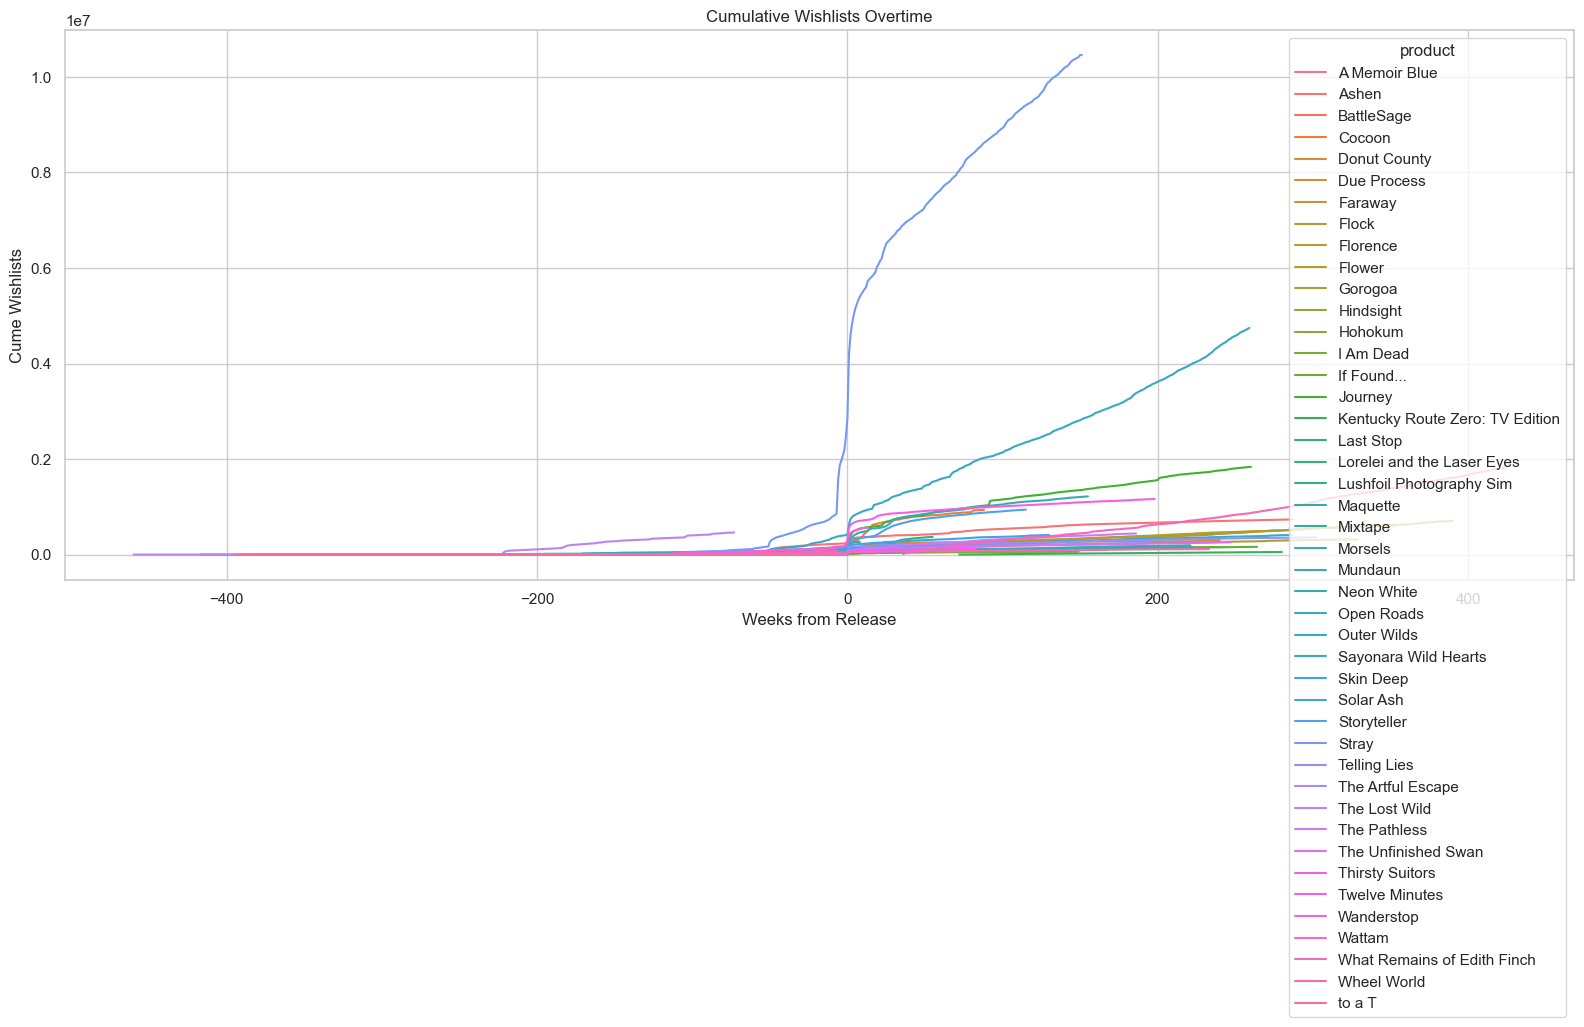

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=df, x="Weeks_from_Release", y="cumulative_additions", hue='product')

# Adding titles and labels
plt.title("Cumulative Wishlists Overtime")
plt.xlabel("Weeks from Release")
plt.ylabel("Cume Wishlists")

# Show the plot
plt.tight_layout()
plt.show()

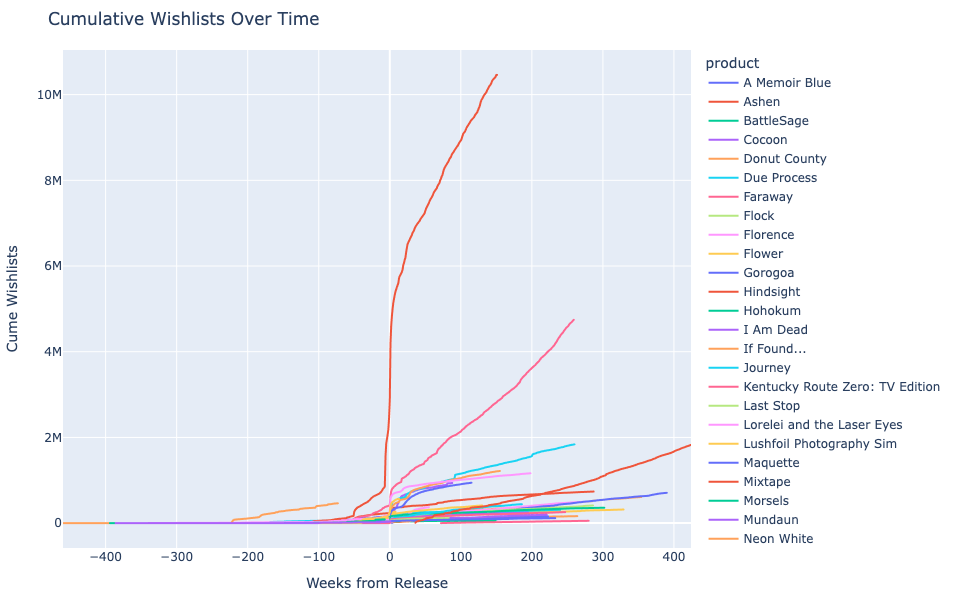

In [42]:
import plotly.express as px

# Create the interactive line plot
fig = px.line(df, 
              x="Weeks_from_Release", 
              y="cumulative_additions", 
              color='product',
              title="Cumulative Wishlists Over Time",
              labels={
                  "Weeks_from_Release": "Weeks from Release",
                  "cumulative_additions": "Cume Wishlists"
              })

# Update the layout for better aesthetics
fig.update_layout(
    autosize=True,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20),
    hovermode='closest'
)

# Save as HTML
fig.write_html("docs/cumulative_wishlists_overtime.html")

# Show the interactive plot
fig.show()

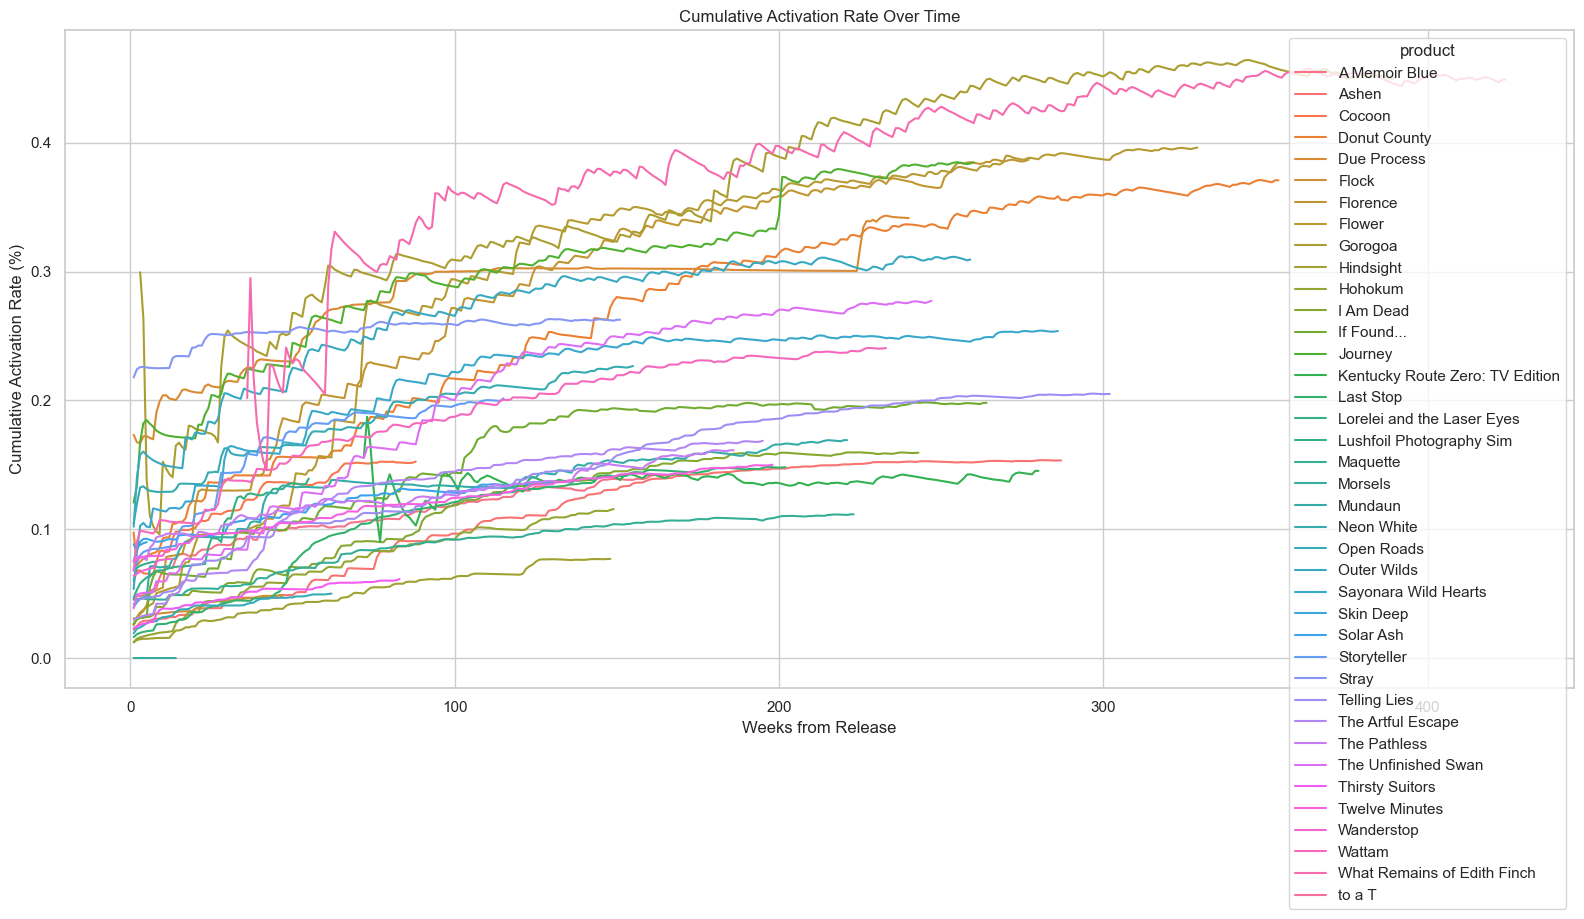

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="cumulative_act_rate", hue='product')


# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

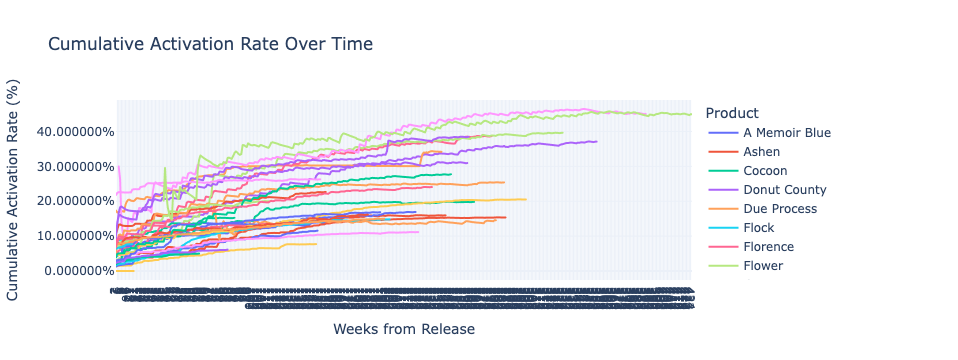

In [44]:
import plotly.express as px

# Create the Plotly line plot
fig = px.line(
    act_rate_df,
    x="Weeks_from_Release",
    y="cumulative_act_rate",
    color='product',
    title="Cumulative Activation Rate Over Time",
    labels={
        "Weeks_from_Release": "Weeks from Release",
        "cumulative_act_rate": "Cumulative Activation Rate (%)"
    },
    template='plotly_white'
)

# Improve layout for readability
fig.update_layout(
    legend_title_text='Product',
    xaxis=dict(tickmode='linear'),
    yaxis_tickformat='%'
)

# Display the plot
fig.show()

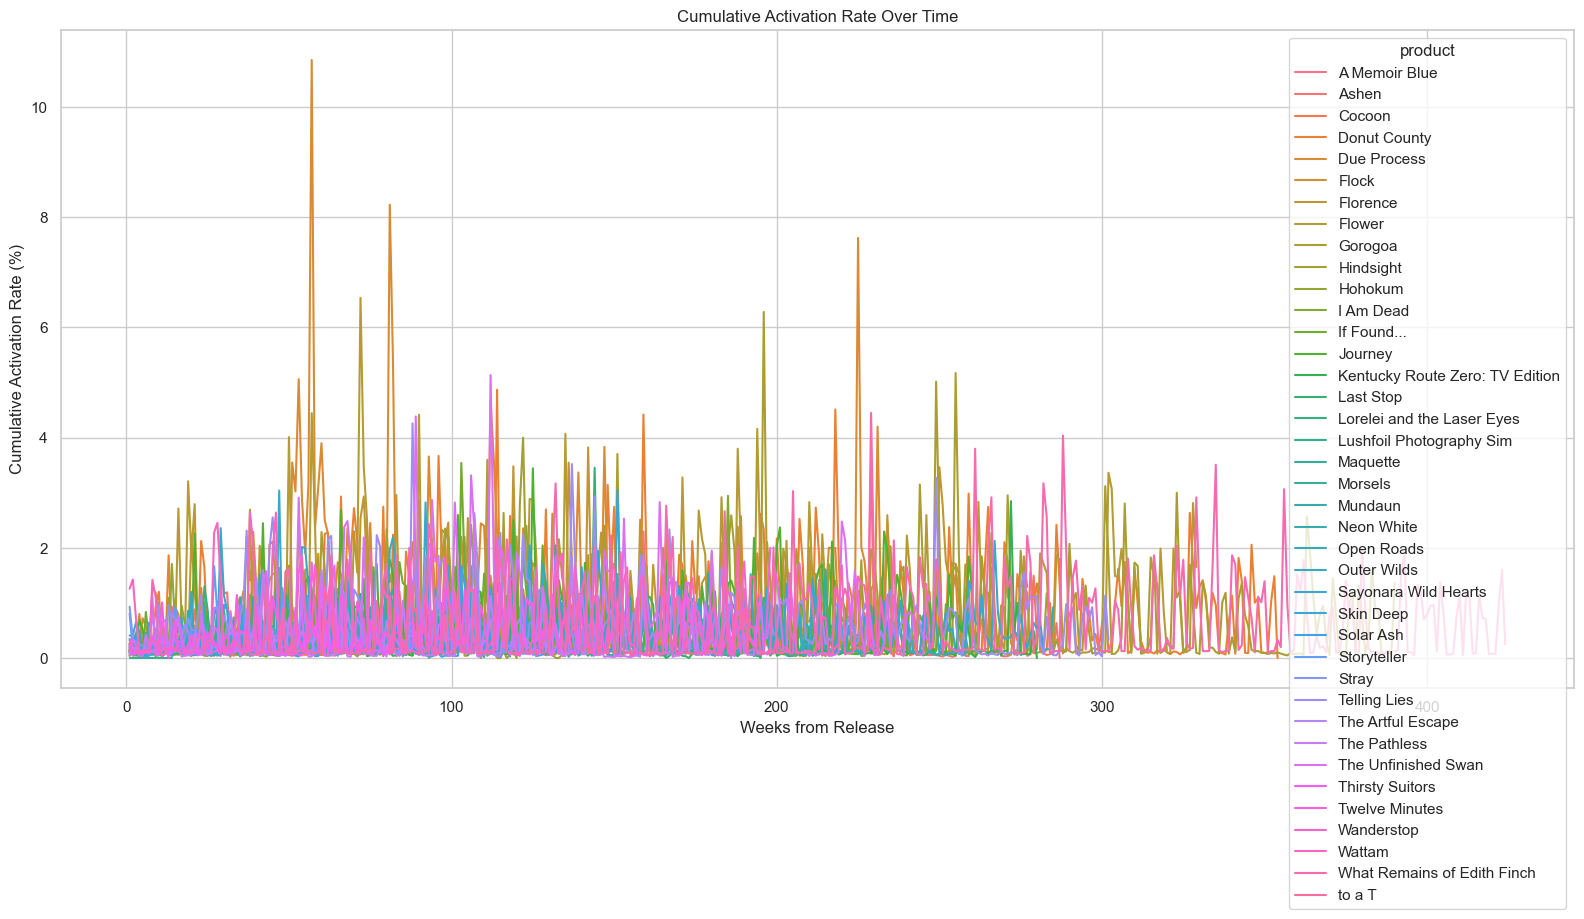

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="act_rate", hue='product')

#plt.ylim(1,25)

# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

In [46]:
INTERACTIVE_HISTORICAL_TABLE = df.query("Weeks_from_Release <=0").sort_values(by='Weeks_from_Release').drop_duplicates(subset="product", keep='last')

In [47]:
INTERACTIVE_HISTORICAL_TABLE.to_clipboard()

In [48]:
INTERACTIVE_HISTORICAL_TABLE

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
13046,The Lost Wild,-73.0,295,461811,1,0.000000,0.000002
2355,Faraway,-30.0,6,5312,0,0.000000,0.000000
8000,Mixtape,-30.0,82,85667,0,0.000000,0.000000
16153,Wheel World,-7.0,90,87079,0,0.000000,0.000000
1163,BattleSage,-3.0,0,3215,3,NaN,0.000933
9682,Outer Wilds,0.0,5880,422721,22,0.003231,0.000052
10043,Sayonara Wild Hearts,0.0,0,0,0,NaN,NaN
7215,Lushfoil Photography Sim,0.0,2522,148101,2,0.000000,0.000014
9491,Open Roads,0.0,1867,106435,1,0.000000,0.000010
8374,Morsels,0.0,1779,39843,3,0.000000,0.000086
